# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import seaborn as sns

## Data Preparation

In this step, we prepare the dataset for causal analysis. This includes:

- Converting the date column to datetime format
- Filtering the dataset to a relevant time window (2019–2021)
- Ensuring consistency in observations across cities and time

We focus on this period to capture:
- Pre-COVID baseline (2019)
- COVID intervention period (2020–2021)

This allows us to compare air quality before and after lockdowns.

In [2]:
from google.colab import files
uploaded = files.upload()

Saving merged_daily_aqi.csv to merged_daily_aqi.csv


In [3]:
df = pd.read_csv("/content/merged_daily_aqi.csv")

In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

print("\nData types:")
print(df.dtypes)

Shape: (28519, 9)

Columns:
['date', 'city', 'country', 'location', 'aqi', 'pm25', 'aqi_method', 'source_dataset', 'raw_row_count']

First 5 rows:
         date       city country          location    aqi  pm25 aqi_method  \
0  2015-05-01      Delhi   India      Delhi, India  221.0   NaN   provided   
1  2015-05-02  Bengaluru   India  Bengaluru, India  132.0   NaN   provided   
2  2015-05-02      Delhi   India      Delhi, India  238.0   NaN   provided   
3  2015-05-03  Bengaluru   India  Bengaluru, India   49.0   NaN   provided   
4  2015-05-03      Delhi   India      Delhi, India  259.0   NaN   provided   

        source_dataset  raw_row_count  
0  India AQI Bulletins              1  
1  India AQI Bulletins              1  
2  India AQI Bulletins              1  
3  India AQI Bulletins              1  
4  India AQI Bulletins              1  

Data types:
date               object
city               object
country            object
location           object
aqi               float64
p

Text(0.5, 1.0, 'Missing Values Visualization')

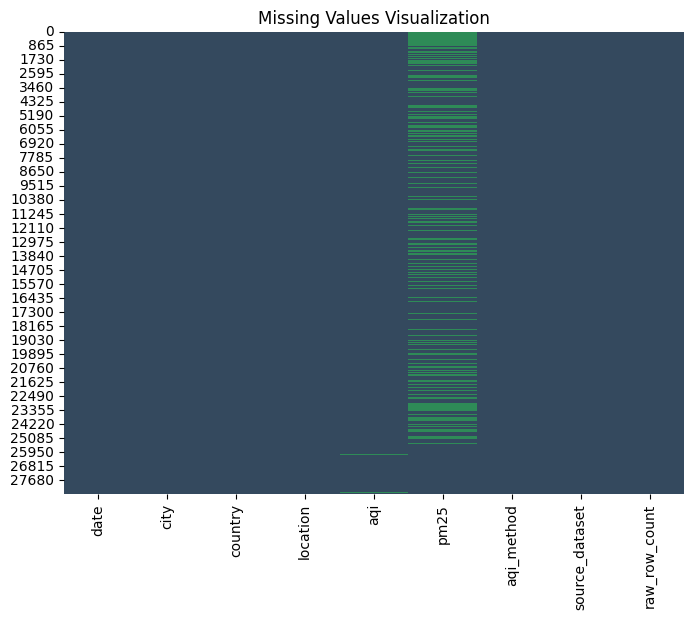

In [5]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.isnull(), cbar=False, cmap=['#34495E', 'seagreen']) # Use a specific colormap
plt.title("Missing Values Visualization")

In [6]:
print("Total missing AQI:", df["aqi"].isnull().sum())

Total missing AQI: 95


In [7]:
missing_aqi = df[df["aqi"].isnull()]
missing_aqi.head()

,date,city,country,location,aqi,pm25,aqi_method,source_dataset,raw_row_count
1085,2016-05-06,London,United Kingdom,"London, United Kingdom",NaN,35.4792,derived_from_pm25,Other Cities PM2.5,1
1277,2016-06-16,London,United Kingdom,"London, United Kingdom",NaN,12.0765,derived_from_pm25,Other Cities PM2.5,1
1287,2016-06-18,London,United Kingdom,"London, United Kingdom",NaN,12.0917,derived_from_pm25,Other Cities PM2.5,1
1668,2016-09-12,London,United Kingdom,"London, United Kingdom",NaN,12.0521,derived_from_pm25,Other Cities PM2.5,1
2454,2017-02-17,Berlin,Germany,"Berlin, Germany",NaN,12.0706,derived_from_pm25,Other Cities PM2.5,1


In [8]:
missing_aqi["city"].value_counts()


,count
city,
Paris,51
Berlin,13
London,11
Sao Paulo,8
Mexico City,7
Tokyo,5


In [9]:
unique_countries = df['location'].nunique()
unique_countries

17

In [10]:
rows_per_location = df.groupby('location').size()
rows_per_location

,0
location,
"Bengaluru, India",3120
"Berlin, Germany",2274
"Boston, USA",1096
"Chicago, USA",1096
"Delhi, India",3143
"Houston, USA",1096
"London, United Kingdom",2483
"Los Angeles, USA",1096
"Mexico City, Mexico",1813


In [11]:
missing_pct = df.groupby("city")["aqi"].apply(lambda x: x.isnull().mean())
missing_pct.sort_values(ascending=False)

,aqi
city,
Paris,0.020893
Sao Paulo,0.009313
Berlin,0.005717
Tokyo,0.005198
London,0.004430
Mexico City,0.003861
Bengaluru,0.000000
Delhi,0.000000
Boston,0.000000


## Handling Missing Values

We examine missing values in the dataset to ensure data quality.

- AQI is our primary outcome variable, so missing AQI values are removed
- PM2.5 contains a large number of missing values and is excluded from the analysis

This ensures that our analysis is based on reliable and consistent measurements.

In [12]:
df = df.dropna(subset=["aqi"])

print("After dropping missing AQI:", df.shape)

After dropping missing AQI: (28424, 9)


In [14]:
df = df.drop(columns=["pm25"])

print(df.isnull().sum())

date              0
city              0
country           0
location          0
aqi               0
aqi_method        0
source_dataset    0
raw_row_count     0
dtype: int64


Text(0.5, 1.0, 'Missing Values After Cleaning')

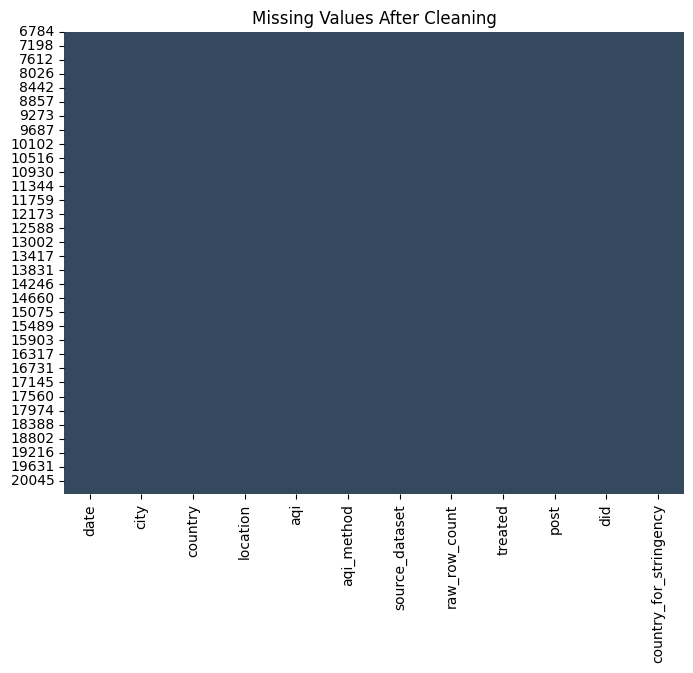

In [38]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.isnull(), cbar=False, cmap=['#34495E', 'seagreen'])
plt.title("Missing Values After Cleaning")

In [17]:
print("After dropping missing PM25:", df.shape)

After dropping missing PM25: (28424, 8)


In [18]:
df["city"].unique()

array(['Delhi', 'Bengaluru', 'Mumbai', 'London', 'Mexico City', 'Berlin',
       'Paris', 'Sao Paulo', 'Boston', 'Chicago', 'Houston',
       'Los Angeles', 'New York', 'Phoenix', 'San Francisco', 'Seoul',
       'Tokyo'], dtype=object)

## Defining Treatment Groups

We classify countries into treatment and control groups based on COVID-19 policy stringency.

- Treated group: Countries with higher average lockdown stringency
- Control group: Countries with relatively lower stringency

This classification is based on external policy data (Oxford Stringency Index) and allows us to compare the impact of stricter vs weaker lockdowns.

In [20]:
url = "https://raw.githubusercontent.com/OxCGRT/covid-policy-tracker/main/data/OxCGRT_latest.csv"

stringency_df = pd.read_csv(url)

print(stringency_df.shape)
stringency_df.head()

(103040, 49)


/tmp/ipykernel_19182/3494239678.py:3: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  stringency_df = pd.read_csv(url)


,CountryName,CountryCode,RegionName,RegionCode,Jurisdiction,Date,C1_School closing,C1_Flag,C2_Workplace closing,C2_Flag,...,StringencyIndex,StringencyIndexForDisplay,StringencyLegacyIndex,StringencyLegacyIndexForDisplay,GovernmentResponseIndex,GovernmentResponseIndexForDisplay,ContainmentHealthIndex,ContainmentHealthIndexForDisplay,EconomicSupportIndex,EconomicSupportIndexForDisplay
0,Aruba,ABW,NaN,NaN,NAT_TOTAL,20200101,0.0,NaN,0.0,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Aruba,ABW,NaN,NaN,NAT_TOTAL,20200102,0.0,NaN,0.0,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Aruba,ABW,NaN,NaN,NAT_TOTAL,20200103,0.0,NaN,0.0,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Aruba,ABW,NaN,NaN,NAT_TOTAL,20200104,0.0,NaN,0.0,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Aruba,ABW,NaN,NaN,NAT_TOTAL,20200105,0.0,NaN,0.0,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
stringency_df = stringency_df[["CountryName", "Date", "StringencyIndex"]]

stringency_df["Date"] = pd.to_datetime(stringency_df["Date"], format="%Y%m%d")

stringency_df = stringency_df[
    (stringency_df["Date"] >= "2020-03-01") &
    (stringency_df["Date"] <= "2020-06-01")
]

print(stringency_df.shape)
stringency_df.head()

(26040, 3)


,CountryName,Date,StringencyIndex
60,Aruba,2020-03-01,0.0
61,Aruba,2020-03-02,0.0
62,Aruba,2020-03-03,0.0
63,Aruba,2020-03-04,0.0
64,Aruba,2020-03-05,0.0


In [22]:
country_stringency = stringency_df.groupby("CountryName")["StringencyIndex"].mean().reset_index()

country_stringency = country_stringency.sort_values("StringencyIndex", ascending=False)

country_stringency.head(10)

,CountryName,StringencyIndex
125,Palestine,86.949892
130,Philippines,86.211828
73,Honduras,85.951613
80,Iraq,84.639677
63,Georgia,83.772688
90,Kuwait,82.765914
69,Guatemala,82.708172
129,Peru,81.986667
20,Bolivia,81.691398
52,El Salvador,81.520215


In [23]:
df["country"].unique()

array(['India', 'United Kingdom', 'Mexico', 'Germany', 'France', 'Brazil',
       'USA', 'South Korea', 'Japan'], dtype=object)

In [37]:
country_map = {
    "USA": "United States"
}

df["country_for_stringency"] = df["country"].replace(country_map)

your_countries = df["country_for_stringency"].unique()

filtered_stringency = country_stringency[
    country_stringency["CountryName"].isin(your_countries)
]

filtered_stringency.sort_values("StringencyIndex", ascending=False)

,CountryName,StringencyIndex
77,India,78.166344
60,France,77.785484
23,Brazil,71.246937
174,United States,64.682915
173,United Kingdom,63.215161
64,Germany,62.971290
108,Mexico,61.476774
150,South Korea,57.468817


In [25]:
treated_countries = ["India", "France", "Brazil"]

df["treated"] = df["country"].isin(treated_countries).astype(int)

df[["country", "treated"]].drop_duplicates().sort_values("treated", ascending=False)

,country,treated
0,India,1
2453,France,1
3333,Brazil,1
819,Mexico,0
668,United Kingdom,0
1997,Germany,0
6789,USA,0
14762,South Korea,0
24260,Japan,0


## Defining Pre and Post Periods

We create a time indicator to distinguish between:

- Pre-COVID period (before March 15, 2020)
- Post-COVID period (after March 15, 2020)

This variable enables us to measure how air quality changed after the onset of lockdown policies.

In [26]:

df["date"] = pd.to_datetime(df["date"])
# filter to study window
df = df[(df["date"] >= "2019-01-01") & (df["date"] <= "2021-12-31")]
print(df.shape)
print(df["date"].min(), "to", df["date"].max())

(13640, 9)
2019-01-01 00:00:00 to 2021-12-31 00:00:00


In [27]:
df["post"] = (df["date"] >= "2020-03-15").astype(int)

df[["date", "post"]].head(10)

,date,post
6784,2019-01-01,0
6785,2019-01-01,0
6786,2019-01-01,0
6787,2019-01-01,0
6788,2019-01-01,0
6789,2019-01-01,0
6790,2019-01-01,0
6791,2019-01-01,0
6792,2019-01-01,0
6793,2019-01-01,0


In [28]:
df["post"].value_counts()

,count
post,
1,8165
0,5475


## Difference-in-Differences (DiD) Variable

We construct the key interaction term:

- `did = treated × post`

This variable captures the effect of lockdowns by identifying observations that are:
- In treated countries
- During the post-COVID period

This is the core variable used to estimate the causal effect.

In [29]:
df["did"] = df["treated"] * df["post"]

df[["treated", "post", "did"]].head(10)

,treated,post,did
6784,1,0,0
6785,0,0,0
6786,1,0,0
6787,1,0,0
6788,1,0,0
6789,0,0,0
6790,0,0,0
6791,0,0,0
6792,0,0,0
6793,0,0,0


In [30]:
df['did'].value_counts()

,count
did,
0,11269
1,2371


In [31]:
df.groupby("treated")["aqi"].count()

,aqi
treated,
0,9526
1,4114


## Parallel Trends Assumption Check

Before applying Difference-in-Differences, we visually assess the parallel trends assumption.

This involves plotting AQI trends for treated and control groups over time.

The goal is to examine whether both groups show reasonably comparable pre-COVID trends. If this assumption is approximately satisfied, we can interpret the estimated effect with greater confidence, while acknowledging limitations in group comparability.

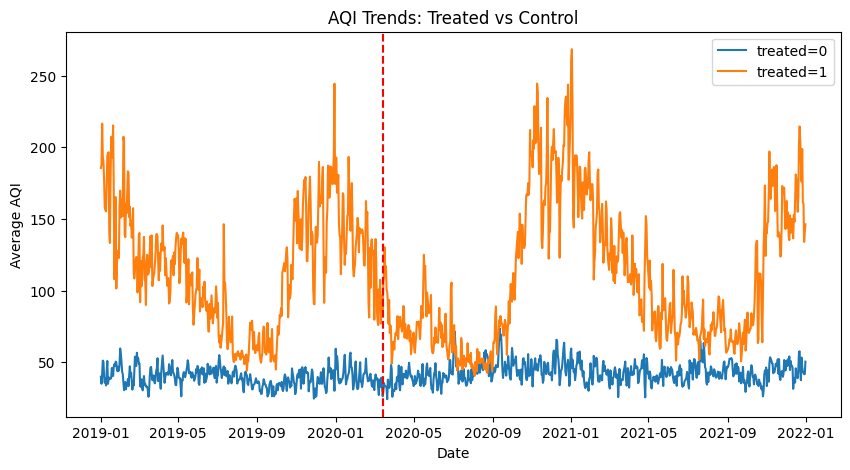

In [32]:
trend = df.groupby(["date", "treated"])["aqi"].mean().reset_index()

plt.figure(figsize=(10,5))

for t in [0, 1]:
    subset = trend[trend["treated"] == t]
    plt.plot(subset["date"], subset["aqi"], label=f"treated={t}")

plt.axvline(pd.to_datetime("2020-03-15"), color="red", linestyle="--")

plt.legend()
plt.title("AQI Trends: Treated vs Control")
plt.xlabel("Date")
plt.ylabel("Average AQI")

plt.show()

## Difference-in-Differences Regression Model

We estimate the causal effect using the following regression model:

AQI = β0 + β1(Treated) + β2(Post) + β3(Treated × Post) + ε

Where:
- `treated` captures baseline differences between groups
- `post` captures overall time effects
- `did` (interaction term) captures the causal effect of lockdowns

The coefficient of `did` represents the estimated impact of stricter lockdowns on air pollution.

In [33]:
model = smf.ols("aqi ~ treated + post + did", data=df).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    aqi   R-squared:                       0.289
Model:                            OLS   Adj. R-squared:                  0.289
Method:                 Least Squares   F-statistic:                     1847.
Date:                Wed, 01 Apr 2026   Prob (F-statistic):               0.00
Time:                        21:46:01   Log-Likelihood:                -72803.
No. Observations:               13640   AIC:                         1.456e+05
Df Residuals:                   13636   BIC:                         1.456e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     39.7245      0.824     48.214      0.0

In [34]:
did_plot = df.groupby(["treated", "post"])["aqi"].mean().reset_index()

did_plot

,treated,post,aqi
0,0,0,39.724542
1,0,1,43.195721
2,1,0,116.307516
3,1,1,107.956558


## Difference-in-Differences Visualization

We visualize the average AQI for treated and control groups before and after COVID.

This plot shows:
- Change in AQI for control group
- Change in AQI for treated group

The difference between these changes represents the DiD estimate, which captures the impact of lockdown policies on air quality.

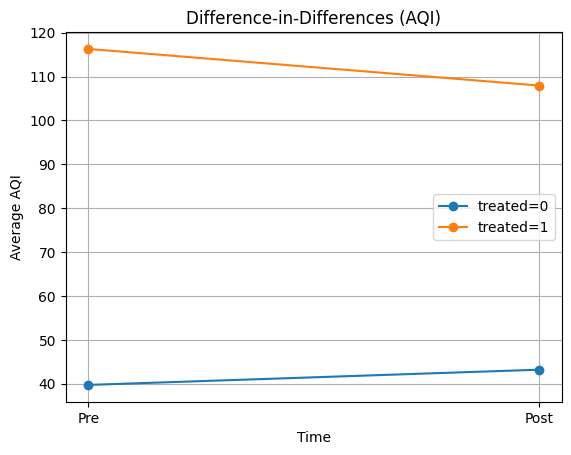

In [36]:
for t in [0, 1]:
    subset = did_plot[did_plot["treated"] == t]
    plt.plot(subset["post"], subset["aqi"], marker='o', label=f"treated={t}")

plt.xticks([0,1], ["Pre", "Post"])
plt.xlabel("Time")
plt.ylabel("Average AQI")
plt.title("Difference-in-Differences (AQI)")
plt.legend()
plt.grid(True)

plt.show()

## Results Interpretation

The coefficient of the interaction term (`did`) represents the Difference-in-Differences estimate.

- A negative value indicates a reduction in AQI (improvement in air quality)
- Statistical significance suggests the effect is unlikely due to chance

Our results indicate that countries with stricter lockdowns experienced a larger reduction in air pollution compared to those with weaker restrictions.

This supports the hypothesis that lockdown policies contributed to improved air quality.